In [2]:
%load_ext autoreload
%autoreload 2
import os
import math

import matplotlib.pyplot as plt
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm
import numpy as np
from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import sample_8gaussians, sample_moons, torch_wrapper

savedir = "models/2d"
os.makedirs(savedir, exist_ok=True)

In [3]:
def eight_normal_sample(n, dim=2, scale=5, var=0.3):
    m = torch.distributions.multivariate_normal.MultivariateNormal(
        torch.zeros(dim), var * torch.eye(dim)
    )
    centers = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1),
        (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
    ]
    centers = torch.tensor(centers) * scale
    noise = m.sample((n,))
    multi = torch.multinomial(torch.ones(8), n, replacement=True)
    data = []
    for i in range(n):
        data.append(centers[multi[i]] + noise[i])
    data = torch.stack(data)
    return data
    
def eight_normal_log_prob(x, dim=2, scale=5, var=0.3):
    centers = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1),
        (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
    ]
    centers = torch.tensor(centers) * scale
    
    # Compute per-component densities
    sigma2 = var
    normalization = -0.5 * dim * torch.log(2 * torch.tensor(np.pi) * sigma2)
    log_probs = []
    for center in centers:
        log_prob = normalization - torch.sum((x - center) ** 2, dim=-1) / (2 * sigma2)
        log_probs.append(log_prob)
    log_probs = torch.stack(log_probs, dim=-1)
    # Log-sum-exp trick for numerical stability
    max_log_prob, _ = torch.max(log_probs, dim=-1, keepdim=True)
    mixture_log_prob = max_log_prob + torch.log(torch.sum(torch.exp(log_probs - max_log_prob), dim=-1, keepdim=True)) - torch.log(torch.tensor(len(centers))).squeeze()
    return mixture_log_prob

class torch_wrapper(torch.nn.Module):
    """Wraps model to torchdyn compatible format."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, t, x, *args, **kwargs):
        return self.model(torch.cat([x, t.repeat(x.shape[0])[:, None]], 1))

class torch_shortcut_wrapper(torch.nn.Module):
    """Wraps model to torchdyn compatible format."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, t, x, *args, **kwargs):
        dt_base_bootstrap = torch.zeros_like(t)
        return self.model(torch.cat([x, 
                                     t.repeat(x.shape[0])[:, None], 
                                    dt_base_bootstrap.repeat(x.shape[0])[:, None]], 1))


def exact_div_fn(u):
    """Accepts a function u:R^D -> R^D."""
    J = torch.func.jacrev(u)
    jac = lambda x, *args: J(x)
    return jac
    # return lambda x, *args: torch.trace(J(x))


def div_fn_hutch_trace(u):
    def div_fn(x, eps):
        _, vjpfunc = torch.func.vjp(u, x)
        return (vjpfunc(eps)[0] * eps).sum()

    return div_fn


class cnf_wrapper(torch.nn.Module):
    """Wraps model to a torchdyn compatible CNF format.
    Appends an additional dimension representing the change in likelihood
    over time.
    """

    def __init__(self, model, likelihood_estimator="exact"):
        super().__init__()
        self.model = model
        self.div_fn, self.eps_fn = self.get_div_and_eps(likelihood_estimator)

    def get_div_and_eps(self, likelihood_estimator):
        if likelihood_estimator == "exact":
            return exact_div_fn, None
        if likelihood_estimator == "hutch_gaussian":
            return div_fn_hutch_trace, torch.randn_like
        if likelihood_estimator == "hutch_rademacher":

            def eps_fn(x):
                return torch.randint_like(x, low=0, high=2).float() * 2 - 1.0

            return div_fn_hutch_trace, eps_fn
        raise NotImplementedError(
            f"likelihood estimator {likelihood_estimator} is not implemented"
        )

    def forward(self, t, x, *args, **kwargs):
        t = t.squeeze()
        x = x[..., :-1]

        def vecfield(y):
            return self.model(torch.cat([y, t[None]]))

        if self.eps_fn is None:
            div = torch.vmap(self.div_fn(vecfield))(x)
        else:
            div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        dx = self.model(torch.cat([x, t.repeat(x.shape[0])[:, None]], 1))
        return torch.cat([dx, div[:, None]], dim=-1)

In [4]:
def plot_trajectories_sb(traj, legend=True, logp=None):
    n = 2000
    plt.figure(figsize=(10, 10))
    plt.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    plt.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    if logp is None:
        plt.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")
    else:
        plt.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c=logp.detach())
        
    for i in range(5, 15):
        plt.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")
    if legend:
        plt.legend([r"$p_0$", r"$p_t$", r"$p_1$", r"$X_t \mid X_0$"])
    plt.xticks([])
    plt.yticks([])
    plt.axis("off")

In [5]:
class MLP3(torch.nn.Module):
    def __init__(self, dim, out_dim=None, w=64):
        super().__init__()
        
        if out_dim is None:
            out_dim = dim
        self.net = torch.nn.Sequential(
            torch.nn.Linear(dim + 2, w),
            torch.nn.ReLU(),
            torch.nn.Linear(w, w),
            torch.nn.SiLU(),
            torch.nn.Linear(w, w),
            torch.nn.SiLU(),
            torch.nn.Linear(w, out_dim),
        )

    def forward(self, x):
        return self.net(x)



In [23]:
# --------------------
# Model components
# --------------------
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions as D

class MaskedLinear(nn.Module):
    def __init__(self, in_features, out_features, data_dim):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.data_dim = data_dim

        # Notation:
        # BNAF weight calculation for (eq 8): W = g(W) * M_d + W * M_o
        #   where W is block lower triangular so model is autoregressive,
        #         g = exp function; M_d is block diagonal mask; M_o is block off-diagonal mask.
        # Weight Normalization (Salimans & Kingma, eq 2): w = g * v / ||v||
        #   where g is scalar, v is k-dim vector, ||v|| is Euclidean norm
        # ------
        # Here: pre-weight norm matrix is v; then: v = exp(weight) * mask_d + weight * mask_o
        #       weight-norm scalar is g: out_features dimensional vector (here logg is used instead to avoid taking logs in the logdet calc.
        #       then weight-normed weight matrix is w = g * v / ||v||
        #
        #       log det jacobian of block lower triangular is taking block diagonal mask of
        #           log(g*v/||v||) = log(g) + log(v) - log(||v||)
        #                          = log(g) + weight - log(||v||) since v = exp(weight) * mask_d + weight * mask_o

        weight = torch.zeros(out_features, in_features)
        mask_d = torch.zeros_like(weight)
        mask_o = torch.zeros_like(weight)
        for i in range(data_dim):
            # select block slices
            h     = slice(i * out_features // data_dim, (i+1) * out_features // data_dim)
            w     = slice(i * in_features // data_dim,  (i+1) * in_features // data_dim)
            w_row = slice(0,                            (i+1) * in_features // data_dim)
            # initialize block-lower-triangular weight and construct block diagonal mask_d and lower triangular mask_o
            nn.init.kaiming_uniform_(weight[h,w_row], a=math.sqrt(5))  # default nn.Linear weight init only block-wise
            mask_d[h,w] = 1
            mask_o[h,w_row] = 1

        mask_o = mask_o - mask_d  # remove diagonal so mask_o is lower triangular 1-off the diagonal

        self.weight = nn.Parameter(weight)                          # pre-mask, pre-weight-norm
        self.logg = nn.Parameter(torch.rand(out_features, 1).log()) # weight-norm parameter
        self.bias = nn.Parameter(nn.init.uniform_(torch.rand(out_features), -1/math.sqrt(in_features), 1/math.sqrt(in_features)))  # default nn.Linear bias init
        self.register_buffer('mask_d', mask_d)
        self.register_buffer('mask_o', mask_o)

    def forward(self, x, sum_logdets):
        # 1. compute BNAF masked weight eq 8
        v = self.weight.exp() * self.mask_d + self.weight * self.mask_o
        # 2. weight normalization
        v_norm = v.norm(p=2, dim=1, keepdim=True)
        w = self.logg.exp() * v / v_norm
        # 3. compute output and logdet of the layer
        out = F.linear(x, w, self.bias)
        logdet = self.logg + self.weight - 0.5 * v_norm.pow(2).log()
        logdet = logdet[self.mask_d.byte()]
        logdet = logdet.view(1, self.data_dim, out.shape[1]//self.data_dim, x.shape[1]//self.data_dim) \
                       .expand(x.shape[0],-1,-1,-1)  # output (B, data_dim, out_dim // data_dim, in_dim // data_dim)

        # 4. sum with sum_logdets from layers before (BNAF section 3.3)
        # Compute log det jacobian of the flow (eq 9, 10, 11) using log-matrix multiplication of the different layers.
        # Specifically for two successive MaskedLinear layers A -> B with logdets A and B of shapes
        #  logdet A is (B, data_dim, outA_dim, inA_dim)
        #  logdet B is (B, data_dim, outB_dim, inB_dim) where outA_dim = inB_dim
        #
        #  Note -- in the first layer, inA_dim = in_features//data_dim = 1 since in_features == data_dim.
        #            thus logdet A is (B, data_dim, outA_dim, 1)
        #
        #  Then:
        #  logsumexp(A.transpose(2,3) + B) = logsumexp( (B, data_dim, 1, outA_dim) + (B, data_dim, outB_dim, inB_dim) , dim=-1)
        #                                  = logsumexp( (B, data_dim, 1, outA_dim) + (B, data_dim, outB_dim, outA_dim), dim=-1)
        #                                  = logsumexp( (B, data_dim, outB_dim, outA_dim), dim=-1) where dim2 of tensor1 is broadcasted
        #                                  = (B, data_dim, outB_dim, 1)

        sum_logdets = torch.logsumexp(sum_logdets.transpose(2,3) + logdet, dim=-1, keepdim=True)

        return out, sum_logdets


    def extra_repr(self):
        return 'in_features={}, out_features={}, bias={}'.format(
            self.in_features, self.out_features, self.bias is not None
        )

class Tanh(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x, sum_logdets):
        # derivation of logdet:
        # d/dx tanh = 1 / cosh^2; cosh = (1 + exp(-2x)) / (2*exp(-x))
        # log d/dx tanh = - 2 * log cosh = -2 * (x - log 2 + log(1 + exp(-2x)))
        logdet = -2 * (x - math.log(2) + F.softplus(-2*x))
        sum_logdets = sum_logdets + logdet.view_as(sum_logdets)
        return x.tanh(), sum_logdets

class FlowSequential(nn.Sequential):
    """ Container for layers of a normalizing flow """
    def forward(self, x):
        sum_logdets = torch.zeros(1, x.shape[1], 1, 1, device=x.device)
        for module in self:
            x, sum_logdets = module(x, sum_logdets)
        return x, sum_logdets.squeeze()


# --------------------
# Model
# --------------------

class BNAF(nn.Module):
    def __init__(self, data_dim, n_hidden, hidden_dim):
        super().__init__()

        # base distribution for calculation of log prob under the model
        self.register_buffer('base_dist_mean', torch.zeros(data_dim))
        self.register_buffer('base_dist_var', torch.ones(data_dim))

        # construct model
        modules = []
        modules += [MaskedLinear(data_dim, hidden_dim, data_dim), Tanh()]
        for _ in range(n_hidden):
            modules += [MaskedLinear(hidden_dim, hidden_dim, data_dim), Tanh()]
        modules += [MaskedLinear(hidden_dim, data_dim, data_dim)]
        self.net = FlowSequential(*modules)

        # TODO --   add permutation
        #           add residual gate
        #           add stack of flows

    @property
    def base_dist(self):
        return D.Normal(self.base_dist_mean, self.base_dist_var)

    def forward(self, x):
        return self.net(x)

def compute_kl_qp_loss(model, target_potential_fn, batch_size):
    """ Compute BNAF eq 3 & 20:
    KL(q_inv||p) where q_inv is the inverse flow transform (log_q_inv = log_q_base - logdet), p is the target distribution (energy potential)
    Returns the minimization objective for density matching. """
    z = model.base_dist.sample((batch_size,))
    q_log_prob = model.base_dist.log_prob(z)
    zk, logdet = model(z)
    p_log_prob = - target_potential_fn(zk)  # p = exp(-potential) => log_p = - potential
    return q_log_prob.sum(1) - logdet.sum(1) - p_log_prob  # BNAF eq 20

def compute_kl_pq_loss(model, sample_2d_data_fn, batch_size):
    """ Compute BNAF eq 2 & 16:
    KL(p||q_fwd) where q_fwd is the forward flow transform (log_q_fwd = log_q_base + logdet), p is the target distribution.
    Returns the minimization objective for density estimation (NLL under the flow since the entropy of the target dist is fixed wrt the optimization) """
    sample = sample_2d_data_fn(batch_size).to(model.base_dist.loc.device)
    z, logdet = model(sample)
    return - torch.sum(model.base_dist.log_prob(z) + logdet, dim=1)

bnaf_model = BNAF(2, 3, 128)
flow_model = MLP3(dim=dim, w=64)

class ComboModel(torch.nn.Module):
    def __init__(self, bnaf_model, flow_model):
        super().__init__()
        self.bnaf_model = bnaf_model
        self.flow_model = flow_model
    def forward(self, x):
        dt = x[:,-1]
        use_bnaf = dt == 0
        v_bnaf = self.bnaf_model(x[:,:-2])[0]
        v_flow = self.flow_model(x)
        return torch.where(use_bnaf[:,None], v_bnaf, v_flow)
model = ComboModel(bnaf_model, flow_model)

In [31]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
device = "cpu"
batch_size = 256
sigma = 0
dim = 2
#model = MLP3(dim=dim, w=64)
optimizer = torch.optim.AdamW(model.parameters(), 0.01, weight_decay=0.1)
eps = 1e-2
k = batch_size // 4
M = 128
bootstrap_every = 8
log2_sections = np.log2(M).astype(np.int32)
num_iterations = 20_000

In [32]:
import torch
import torch.nn.functional as F
import numpy as np
import pdb

def sample_mog(n=10_000, normalize=True):
    full_dataset = sample_8gaussians(n).to(device)
    data_mean = full_dataset.mean(dim=0)  # shape (2,)
    data_std = full_dataset.std(dim=0)    # shape (2,)
    return full_dataset, data_mean, data_std 

def get_targets(model,
                images, 
                force_t=-1, 
                force_dt=-1):

    device = images.device  # Or wherever you’d like your tensors to live (cuda, cpu, etc.)
    info = {}

    # -----------------------------------------------------------------
    #  1) =========== Sample dt. ============
    # -----------------------------------------------------------------
    bootstrap_batchsize = batch_size // bootstrap_every
    log2_sections = int(np.log2(M))

    dt_range = torch.arange(log2_sections, device=device, dtype=torch.int32)  # [0, 1, 2, ..., log2_sections-1]
    dt_array = (log2_sections - 1 - dt_range)  # e.g. [log2_sections-1, ..., 0]
    repeated = dt_array.repeat(bootstrap_batchsize // log2_sections)
    needed = bootstrap_batchsize - repeated.shape[0]
    dt_base = torch.cat([repeated, torch.zeros(needed, device=device, dtype=torch.int32)], dim=0)

    force_dt_vec = torch.ones(bootstrap_batchsize, device=device, dtype=torch.float32) * force_dt
    dt_base = dt_base.to(torch.float32)  # cast to float to match usage below
    dt_base = torch.where(force_dt_vec != -1, force_dt_vec, dt_base)  # if force_dt != -1, use that

    # dt = 1 / (2^(dt_base)) 
    dt = 1.0 / (2.0 ** dt_base)

    dt_base_bootstrap = dt_base + 1.0
    dt_bootstrap = dt / 2.0

    # -----------------------------------------------------------------
    #  2) =========== Sample t. ============
    # -----------------------------------------------------------------
    dt_sections = 2.0 ** dt_base
    # We want to sample t ~ Uniform{0, dt_sections[i]} (integer), then divide by dt_sections[i].
    # This is somewhat trickier to do in a single vectorized call in PyTorch 
    # (because each batch element can have a different max). 
    # We'll do it in a loop for clarity:

    t_list = []
    for i in range(bootstrap_batchsize):
        maxval = int(dt_sections[i].item())  # dt_sections[i] is float, convert to int
        # If maxval == 0 for some reason, clamp to 1 to avoid errors
        if maxval < 1:
            maxval = 1
        # Sample an integer in [0, maxval)
        t_i = torch.randint(low=0, high=maxval, size=(1,), device=device, dtype=torch.int64)
        t_list.append(t_i)

    t = torch.cat(t_list, dim=0).to(torch.float32)      # shape [bootstrap_batchsize]
    t = t / dt_sections                                 # elementwise scale to [0, 1]

    # force_t logic
    force_t_vec = torch.ones(bootstrap_batchsize, device=device, dtype=torch.float32) * force_t
    t = torch.where(force_t_vec != -1, force_t_vec, t)
    t_full = t.view(-1, 1)

    # -----------------------------------------------------------------
    #  3) =========== Generate Bootstrap Targets ============
    # -----------------------------------------------------------------
    x_1 = images[:bootstrap_batchsize]
    x_0 = torch.randn_like(x_1)
    x_t = (1.0 - (1.0 - 1e-5) * t_full) * x_0 + t_full * x_1

    with torch.no_grad():
        v_b1 = model(torch.cat([x_t, t[:, None], dt_base_bootstrap[:, None]], dim=-1))
    
    t2 = t + dt_bootstrap
    x_t2 = x_t + dt_bootstrap.view(-1, 1) * v_b1
    x_t2 = torch.clamp(x_t2, -4.0, 4.0)

    with torch.no_grad():
        v_b2 = model(torch.cat([x_t2, t2[:, None], dt_base_bootstrap[:, None]], dim=-1))

    v_target = 0.5 * (v_b1 + v_b2)
    v_target = torch.clamp(v_target, -4.0, 4.0)

    bst_v = v_target
    bst_dt = dt_base
    bst_t = t
    bst_xt = x_t

    # -----------------------------------------------------------------
    #  4) =========== Generate Flow-Matching Targets ============
    # -----------------------------------------------------------------


    # Sample t uniformly in [0, denoise_timesteps), then / denoise_timesteps
    t_rand = torch.randint(0, M, (images.shape[0],), device=device)
    t_float = t_rand.to(torch.float32) / M

    force_t_vec = torch.ones(images.shape[0], device=device, dtype=torch.float32) * force_t
    t_float = torch.where(force_t_vec != -1, force_t_vec, t_float)
    t_full = t_float.view(-1, 1)

    # x_0 ~ N(0, 1)
    x_0 = torch.randn_like(images)
    x_1 = images

    # x_t = (1 - alpha * t) * x_0 + t * x_1  (with alpha=1-1e-5 in your code)
    x_t_flow = (1.0 - (1.0 - 1e-5) * t_full) * x_0 + t_full * x_1
    v_t_flow = x_1 - (1.0 - 1e-5) * x_0

    dt_flow = int(np.log2(M))
    dt_base_flow = torch.ones(images.shape[0], device=device, dtype=torch.int32) * dt_flow

    # -----------------------------------------------------------------
    #  5) =========== Merge Flow + Bootstrap =============
    # -----------------------------------------------------------------
    bst_size = batch_size // bootstrap_every
    bst_size_data = batch_size - bst_size

    # Combine the bootstrap slices with the flow slices
    x_t_final = torch.cat([bst_xt, x_t_flow[:bst_size_data]], dim=0)
    t_final = torch.cat([bst_t, t_float[:bst_size_data]], dim=0)
    dt_base_final = torch.cat([bst_dt, dt_base_flow[:bst_size_data]], dim=0)
    v_t_final = torch.cat([bst_v, v_t_flow[:bst_size_data]], dim=0)

    # A few diagnostics
    info["bootstrap_ratio"] = torch.mean((dt_base_final != dt_flow).float())
    info["v_magnitude_bootstrap"] = torch.sqrt(torch.mean(bst_v**2))
    info["v_magnitude_b1"] = torch.sqrt(torch.mean(v_b1**2))
    info["v_magnitude_b2"] = torch.sqrt(torch.mean(v_b2**2))

    return x_t_final, v_t_final, t_final, dt_base_final, info


In [33]:
def train():

    for i in tqdm(range(num_iterations)):
        optimizer.zero_grad()
        x_1 = sample_8gaussians(batch_size)
        
        x_t_final, v_t_final, t_final, dt_base_final, info = get_targets(model, x_1)
        v_t_pred = model(torch.cat([x_t_final, t_final[:, None], dt_base_final[:, None]], dim=-1))
        flow_loss = torch.mean((v_t_pred - v_t_final) ** 2, dim=-1)
        loss = flow_loss.mean()
        loss.backward()
        bootstrap_size = batch_size // bootstrap_every
        info['loss_flow'] = torch.mean(flow_loss[bootstrap_size:]).item()
        info['loss_bootstrap'] = torch.mean(flow_loss[:bootstrap_size]).item()
        if (i + 1) % 500 == 0:
            print(f"Step [{i+1}/{num_iterations}] - Flow Loss: {info['loss_flow']:.4f} Bootstrap Loss: {info['loss_bootstrap']:.4f} ")
        optimizer.step()
    return model

model = train()

/tmp/ipykernel_330222/2037023068.py:60: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)                                                                                                                              | 0/20000 [00:00<?, ?it/s]
  logdet = logdet[self.mask_d.byte()]
  3%|████████▏                                                                                                                                                                                                                                                                                                                          | 505/20000 [00:10<07:04, 45.89it/s]

Step [500/20000] - Flow Loss: 5.1169 Bootstrap Loss: 0.1340 


  5%|████████████████▏                                                                                                                                                                                                                                                                                                                 | 1005/20000 [00:21<06:50, 46.24it/s]

Step [1000/20000] - Flow Loss: 5.0832 Bootstrap Loss: 0.1779 


  8%|████████████████████████▏                                                                                                                                                                                                                                                                                                         | 1505/20000 [00:32<06:39, 46.28it/s]

...

Step [19000/20000] - Flow Loss: 4.8126 Bootstrap Loss: 0.1323 


 98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████        | 19509/20000 [07:08<00:10, 45.87it/s]

Step [19500/20000] - Flow Loss: 4.2991 Bootstrap Loss: 0.1757 


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [07:19<00:00, 45.53it/s]

Step [20000/20000] - Flow Loss: 5.3223 Bootstrap Loss: 0.0684 


/tmp/ipykernel_330222/2037023068.py:60: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  logdet = logdet[self.mask_d.byte()]


128


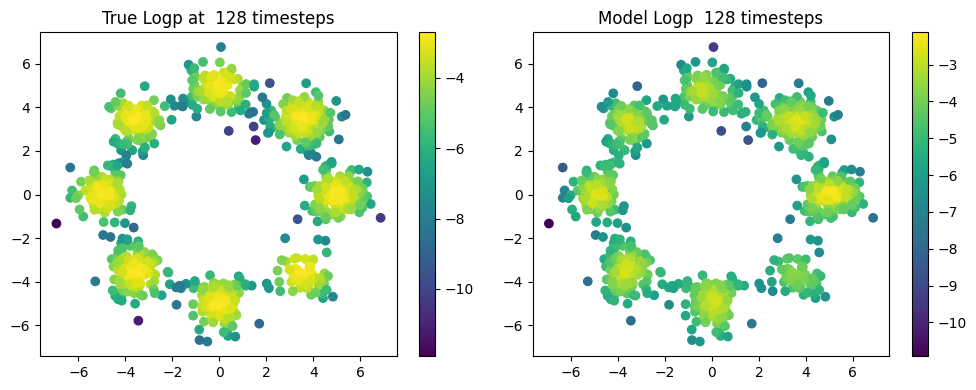

64


<Figure size 640x480 with 0 Axes>

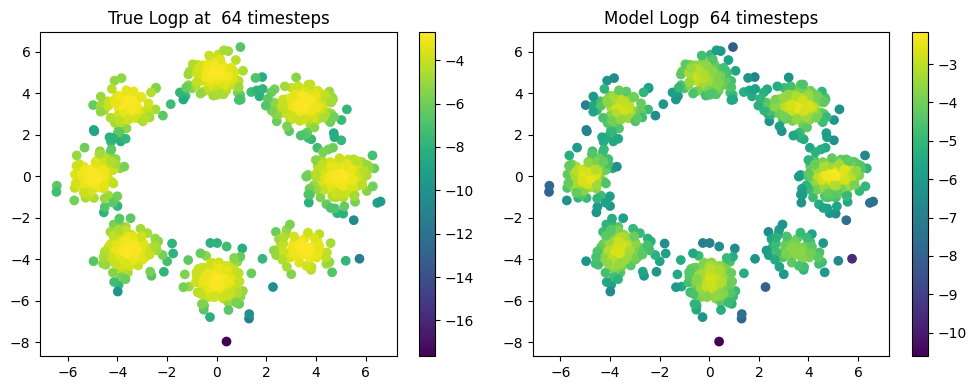

32


<Figure size 640x480 with 0 Axes>

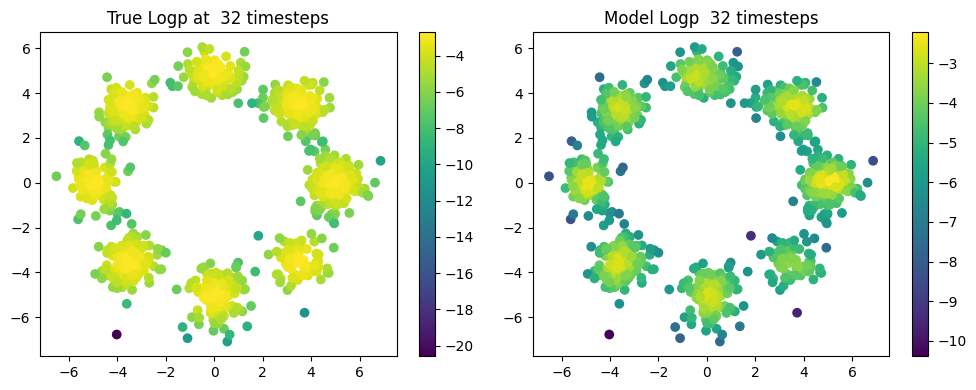

16


<Figure size 640x480 with 0 Axes>

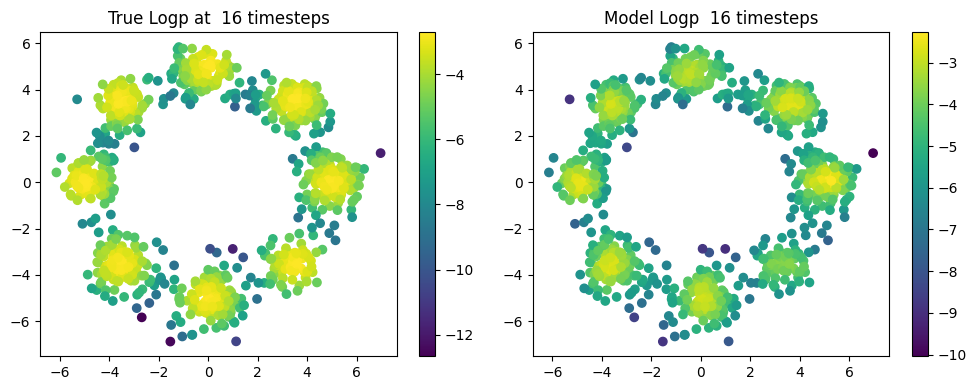

8


<Figure size 640x480 with 0 Axes>

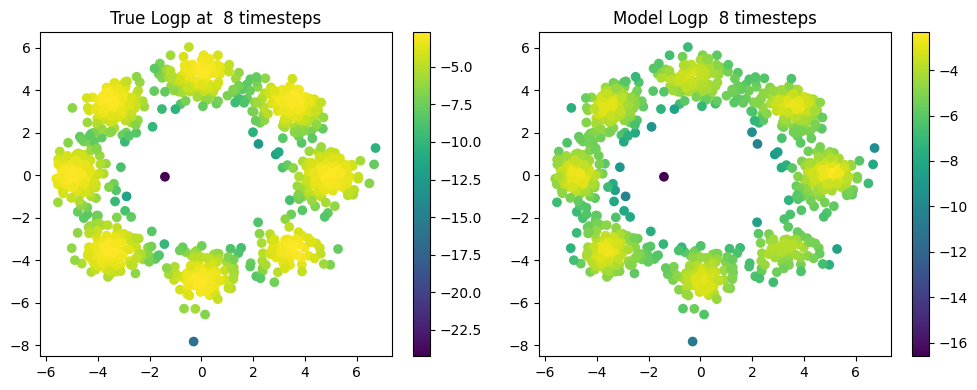

4


<Figure size 640x480 with 0 Axes>

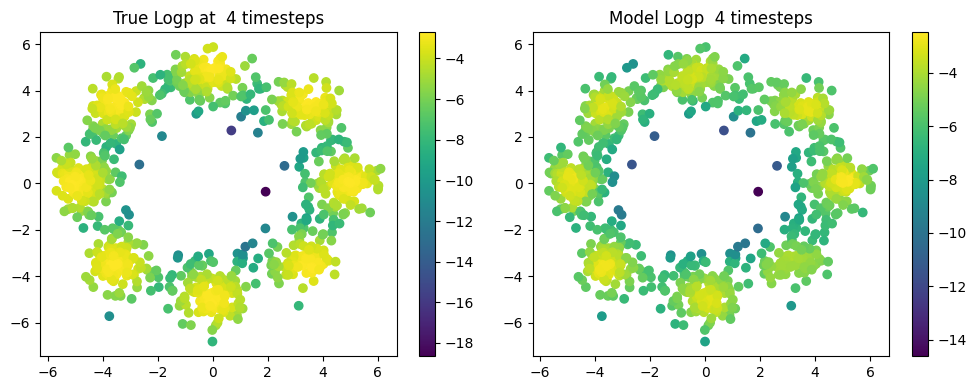

2


<Figure size 640x480 with 0 Axes>

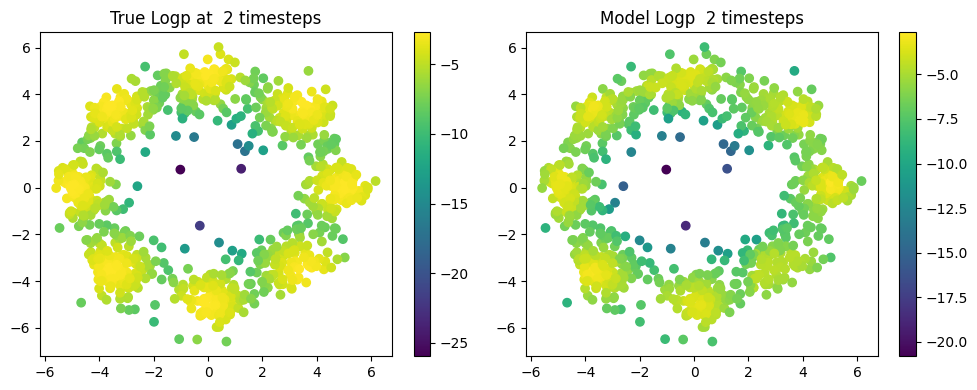

1


<Figure size 640x480 with 0 Axes>

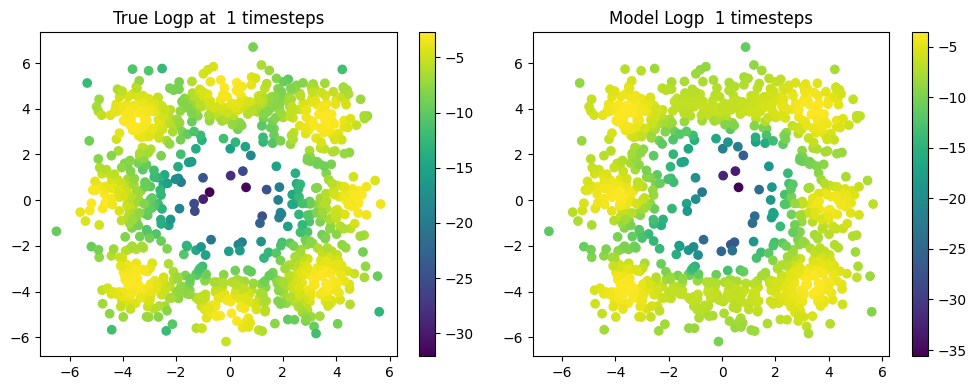

<Figure size 640x480 with 0 Axes>

In [30]:
from torch.distributions import MultivariateNormal
prior = MultivariateNormal(torch.zeros(dim, device=device), torch.eye(dim, device=device))

def shortcut_inference(model, denoise_timesteps=128):
    x0 = torch.randn(1024,2)
    x = x0
    traj = []
    delta_t = 1.0 / denoise_timesteps
    div = 0.0
    for i in range(denoise_timesteps):
        t = i / denoise_timesteps
        
        # Build t_vector with shape [batch_size].
        t_vector = torch.full((x.shape[0],), t, device=device, dtype=torch.float32)
        dt_flow = int(np.log2(denoise_timesteps))
        dt_base = torch.ones(x.shape[0], dtype=torch.int32, device=device) * dt_flow
        v = model(torch.cat([x, t_vector[:, None], dt_base[:, None]], dim=-1))

        def vecfield(y):
            t_in_func = t_vector[0].detach().unsqueeze(0)
            dt_base_in_func = dt_base[0].detach().unsqueeze(0)
            out_v = model(torch.cat([y.unsqueeze(0), t_in_func[:, None], dt_base_in_func[:, None]], dim=-1)).squeeze()
            return out_v

        # Exact Div Calculation 
        jac_fn = torch.func.jacrev(vecfield)
        jac = torch.func.vmap(jac_fn)(x)
        div = div + (jac[:, 0, 0] + jac[:, 1, 1]) * delta_t # God Bless ChatGPT

        # Euler sampling
        x = x + v * delta_t
        traj.append(x.detach())
        
    traj = torch.stack(traj)

    samples = traj[-1]
    # samples = samples*(data_std + 1e-7) + data_mean 
    true_logp = eight_normal_log_prob(samples)
    model_logp = prior.log_prob(x0) - div
    return traj, true_logp, model_logp

log2_sections = int(np.log2(M)) + 1
dt_range = torch.arange(log2_sections, device=device, dtype=torch.int32).flip(dims=(0,))

true_logp_list = []
for denoise_timestep_iter in dt_range:
    denoise_timestep_iter = int((2.0 ** denoise_timestep_iter))
    print(denoise_timestep_iter)
    shortcut_traj, true_logp_samples, model_logp = shortcut_inference(model, denoise_timesteps=denoise_timestep_iter)
    true_logp_list.append(true_logp_samples)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)
    sc1 = ax1.scatter(shortcut_traj[-1][:,0].detach(), shortcut_traj[-1][:,1].detach(), c=true_logp_samples.detach())
    ax1.set_title("True Logp at % d timesteps" % (denoise_timestep_iter))
    sc2 = ax2.scatter(shortcut_traj[-1][:,0].detach(), shortcut_traj[-1][:,1].detach(), c=model_logp.detach())
    ax2.set_title("Model Logp % d timesteps" % (denoise_timestep_iter))
    cbar1 = fig.colorbar(sc1, ax=ax1)
    cbar2 = fig.colorbar(sc2, ax=ax2)
    plt.show()
    plt.clf()


